### A/B Experiment Design: Increasing ARPU via Checkout Recommendations

**Objective**</br>
As a Product Manager of a food delivery app, my goal is to increase Average Revenue Per User (ARPU) by adding recommended add-on items immediately before payment at the checkout.</br>
</br>
**Hypothesis**</br>
Null Hypothesis (H0): ARPU(test) = ARPU(control)</br>
Alternative Hypothesis (H1): ARPU(test) > ARPU(control)</br>

**Experiment Design**</br>
Users are randomly split into two groups:</br>
Control group: After clicking “Go to checkout,” users proceed directly to payment without seeing recommendations.</br>
Test group: After clicking “Go to checkout,” users see a list of recommended items before payment.</br>

**Primary Metric**</br>
Average Revenue per Checkout User (ARPU_checkout, or ARPU) = total order revenue / number of users who reached checkout</br>

**Baseline Metrics**</br>
Current ARPU: **\$27**</br>
Standard deviation = **\$4**</br>
**Target Effect**</br>
Minimal Detectable Effect (MDE): +$1.5</br>

**Guardrail Metrics**</br>
The following metrics should not be downgraded:</br>
- Checkout conversion rate (recommendations may distract users): no statistically significant decrease.</br>
- Time to checkout: increase acceptable if small.</br>
- Order cancellation rate: no statistically significant increase.</br>

**Experiment Plan**</br>
1. Estimate the required sample size based on the baseline ARPU, expected uplift, statistical power, and significance level.</br>
2. The experiment will run until the required sample size is reached, which is expected to take approximately one week based on current checkout traffic.</br>
3. Compare ARPU between groups using a two-sample t-test, assuming approximate normality due to sample size. Calculate the p-value, and Reject H0 if p-value < α (0.05).</br>

In [32]:
import numpy as np
from scipy import stats as sts
from matplotlib import pyplot as plt

#### Formula for calculating sample size
$$n \geq \frac{(Var_{test} + Var_{control})*{(Z_{\frac{\alpha}{2}}+Z_{\beta})}^2}{{MDE}^2}$$

In [10]:
# Parameters for calculating sample size
a = 0.05 # significance level or type I error rate
b = 0.2 # type II error rate
var = 4**2
mde = 1.5

In [13]:
z_a = sts.norm.ppf(1 - a/2)
z_b = sts.norm.ppf(1 - b)

In [14]:
n = (var + var) * (z_a + z_b)**2 / mde**2
print('Sample size for each group:', round(n))

Sample size for each group: 112


In [38]:
# Parameters
n = 112
mu_control = 27
mu_test = 28.5   # MDE = 1.5
sigma = 4
alpha = 0.05

In [39]:
np.random.seed(12)

# Generate data (normal distribution)
control = np.random.normal(mu_control, sigma, n)
test = np.random.normal(mu_test, sigma, n)

In [40]:
print("Control mean:", round(control.mean(), 2))
print("Test mean:", round(test.mean(), 2))

Control mean: 26.41
Test mean: 27.69


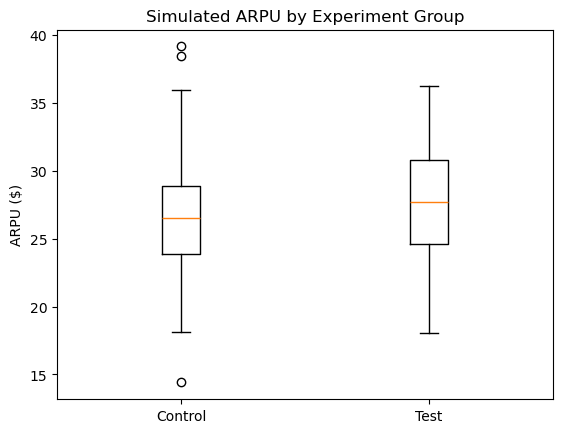

In [49]:
# Visualisation
plt.boxplot([control, test], tick_labels=['Control', 'Test'])
plt.ylabel('ARPU ($)')
plt.title('Simulated ARPU by Experiment Group')
plt.show()

In [69]:
# T-test
t_stat, p_value = sts.ttest_ind(test, control)

print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))
print("Reject H0:", p_value < alpha)

t-statistic: 2.283
p-value: 0.0234
Reject H0: True


**Test Explanation**</br>
A two-sample t-test was conducted to compare ARPU between the test and control groups.</br>
The test assumes:</br>

- Independent samples</br>
- Approximately normal distribution of ARPU</br>
- Equal variances across groups</br>

**Results**</br>

The simulated experiment produced the following sample statistics:</br>

- Mean ARPU (Control): **\$26.41** </br>  
- Mean ARPU (Test): **\$27.69**  </br>
- Observed uplift: $1.28 (+4.8%)</br>

The experiment was powered to detect an uplift of **\$1.5**; the observed uplift of \$1.28 reflects normal sampling variability.</br>


**Conclusion**</br>
The simulated experiment provides statistically significant evidence that displaying recommended items before checkout can increase ARPU.</br>


If the guardrail metrics (checkout conversion rate, time to checkout, and order cancellation rate) are not being negatively impacted, the feature can be considered for rollout.</br>

### Guardrail Metric: Checkout Conversion Rate

Assumptions:</br>

- Baseline conversion ≈ 75%</br>
- The new feature should not reduce conversion rate</br>

H0: The conversion rate is the same for the test and control groups.</br>
H1: The conversion rate differs between the test and control groups.</br>

A one-sided two-proportion z-test is used.

In [60]:
from statsmodels.stats.proportion import proportions_ztest 

np.random.seed(3)

p_test = 0.75
p_control = 0.74

test_group = np.random.binomial(1, p_test, n)
control_group = np.random.binomial(1, p_control, n)

print("Conversion rate (control):", round(control_group.mean(), 3))
print("Conversion rate (test):", round(test_group.mean(), 3))

Conversion rate (control): 0.732
Conversion rate (test): 0.83


In [64]:
z_stat, p_value_two_sided = proportions_ztest([np.sum(test_group), np.sum(control_group)], [len(test_group), len(control_group)]) 
p_value_one_sided = p_value_two_sided / 2

print("Z-statistic:", z_stat)
print("p-value:", p_value_one_sided)
print("Reject H0:", p_value_one_sided < alpha)

Z-statistic: 1.7778684784118925
p-value: 0.03771272918573967
Reject H0: True


**Checkout Conversion Rate: Conclusion**</br>

The test group shows a higher conversion rate than the control group, and the one-sided p-value is below the 5% significance threshold.</br> Therefore, we reject the null hypothesis and conclude that displaying recommendations before payment does not reduce checkout conversion.</br>

From a conversion standpoint, the recommendation feature is considered safe to roll out.

### Guardrail Metric: Time to Checkout

Assumptions:</br>

- Baseline time to checkout: 90 seconds.</br>

H0: Mean time to checkout is the same for test and control groups. </br> 
H1: Mean time to checkout differs between test and control groups.</br>

A two-sample t-test is used to compare average checkout time.

In [71]:
from scipy import stats
import numpy as np

np.random.seed(42)

# Simulate checkout time (seconds)
n = 112
control_time = np.random.normal(loc=90, scale=15, size=n)
test_time = np.random.normal(loc=92, scale=15, size=n)

# t-test
t_stat, p_value = stats.ttest_ind(test_time, control_time)
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 4))

# Means for interpretation
print("Mean checkout time (control):", round(control_time.mean(), 2))
print("Mean checkout time (test):", round(test_time.mean(), 2))
print("Reject H0:", p_value < alpha)

T-statistic: 2.794
P-value: 0.0057
Mean checkout time (control): 88.28
Mean checkout time (test): 93.7
Reject H0: True


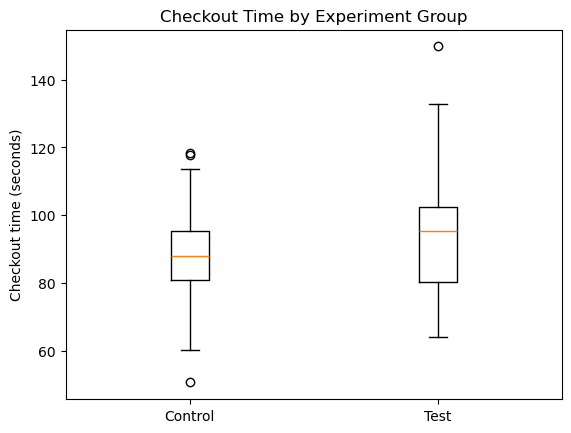

In [68]:
plt.boxplot([control_time, test_time], tick_labels=['Control', 'Test'])
plt.ylabel('Checkout time (seconds)')
plt.title('Checkout Time by Experiment Group')
plt.show()

**Time to Checkout: Conclusion**</br>
A statistically significant increase in time to checkout was observed in the test group (p = 0.0057).  </br>
The average checkout time increased by approximately 5 seconds, which is consistent with the additional recommendation step.</br>

Given the small magnitude of the increase, this impact is considered acceptable from a UX perspective and does not block feature rollout, subject to monitoring conversion-related guardrails.</br>


### Guardrail Metric: Order Cancellation Rate

**Metric definition**</br>
Order cancellation rate = share of orders that were cancelled</br>
Binary outcome:</br>
1 = order cancelled</br>
0 = order completed</br>

Assumptions:</br>

- Baseline cancellation rate = 5%</br>
- New feature should not materially increase cancellations</br>

**Statistical considerations**</br>
Cancellation rate is a rare event.</br>
With n = 112 users per group:</br>
Expected cancellations = 112 × 0.05 ≈ 5–6 orders</br>

This violates the assumptions of the two-proportion z-test and results in low statistical power.</br>
As a result, formal hypothesis testing is not reliable for this metric within the current experiment size.</br>

**Observed results (directional check only)**</br>

- Control: 6 cancellations (5.4%)</br>
- Test: 7 cancellations (6.3%)</br>

Cancellation rates remained comparable between groups.</br>
Due to low event counts, results are assessed directionally only, and no statistically significant conclusions are drawn.</br>
</br>
**Conclusion**</br>

No alarming increase in order cancellations was observed during the experiment.</br>

## Final Decision
The experiment demonstrates a statistically significant increase in ARPU without material degradation of key guardrail metrics.</br>

The feature can be considered for rollout, with monitoring of checkout time and further optimisation of recommendation relevance.</br>